In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing.cleaner import CombustibilDataCleaner

In [3]:
combustibil = CombustibilDataCleaner()
combustibil.read_csv("merged", "combustibil_data.csv")
combustibil.reapply_types()
combustibil_data = combustibil.get_data()

## Vehicle clustering

One row per vehicle, clustered on consumption and supplier behavior (no time features — midnight timestamps are unreliable).

In [ ]:
PREMIUM_PRODUCTS = {
    "OMV MM Diesel", "OMV MM Diesel Artic", "OMV MMotion95",
    "Motorina Extra", "Motorina Evo D Plus", "EFIX S MOTORINA 55",
}

FEATURES = [
    "n_refills", "total_liters", "total_spend", "avg_fill",
    "n_suppliers", "loyalty_pct", "premium_share",
]


def top_supplier_share(group):
    print("aaa", group["Furnizor"].value_counts().max())
    print("bbb", group["Furnizor"].value_counts().max() / len(group))
    print("ccc: ", 100 * group["Furnizor"].value_counts().max() / len(group))
    print("ddd", len(group))
    return 100 * group["Furnizor"].value_counts().max() / len(group)


vehicle_profiles = (
    combustibil_data.groupby("NumarInmatriculare")
    .apply(
        lambda g: pd.Series({
            "n_refills": len(g),
            "total_liters": g["Cantitate"].sum(),
            "total_spend": g["Valoare"].sum(),
            "avg_fill": g["Cantitate"].mean(),
            "n_suppliers": g["Furnizor"].nunique(),
            "loyalty_pct": top_supplier_share(g),
            "premium_share": g["Produs"].isin(PREMIUM_PRODUCTS).mean() * 100,
        }),
        include_groups=False,
    )
    .reset_index()
)

vehicle_profiles.head()

aaa 84
bbb 0.6885245901639344
ccc:  68.85245901639344
ddd 122
aaa 37
bbb 0.6981132075471698
ccc:  69.81132075471699
ddd 53
aaa 24
bbb 0.5454545454545454
ccc:  54.54545454545455
ddd 44
aaa 51
bbb 1.0
ccc:  100.0
ddd 51
aaa 24
bbb 0.5106382978723404
ccc:  51.06382978723404
ddd 47
aaa 7
bbb 1.0
ccc:  100.0
ddd 7
aaa 7
bbb 0.6363636363636364
ccc:  63.63636363636363
ddd 11
aaa 66
bbb 1.0
ccc:  100.0
ddd 66
aaa 102
bbb 1.0
ccc:  100.0
ddd 102
aaa 37
bbb 1.0
ccc:  100.0
ddd 37
aaa 77
bbb 1.0
ccc:  100.0
ddd 77
aaa 32
bbb 0.6956521739130435
ccc:  69.56521739130434
ddd 46
aaa 48
bbb 0.5647058823529412
ccc:  56.470588235294116
ddd 85
aaa 44
bbb 1.0
ccc:  100.0
ddd 44
aaa 36
bbb 0.5625
ccc:  56.25
ddd 64
aaa 28
bbb 1.0
ccc:  100.0
ddd 28
aaa 63
bbb 1.0
ccc:  100.0
ddd 63
aaa 26
bbb 1.0
ccc:  100.0
ddd 26
aaa 72
bbb 1.0
ccc:  100.0
ddd 72
aaa 53
bbb 0.6162790697674418
ccc:  61.627906976744185
ddd 86
aaa 35
bbb 0.6730769230769231
ccc:  67.3076923076923
ddd 52
aaa 33
bbb 0.75
ccc:  75.0
ddd 44
aaa 1

,NumarInmatriculare,n_refills,total_liters,total_spend,avg_fill,n_suppliers,loyalty_pct,premium_share
0,CJ04HVA,122.0,5089.88,33217.1147,41.720328,3.0,68.852459,0.819672
1,CJ05HVA,53.0,3339.50,22055.2135,63.009434,2.0,69.811321,1.886792
2,CJ06YNS,44.0,3272.71,22343.1149,74.379773,3.0,54.545455,54.545455
3,CJ07HVA,51.0,2325.59,16139.0864,45.599804,1.0,100.000000,74.509804
4,CJ09EXP,47.0,2534.50,17237.5287,53.925532,2.0,51.063830,8.510638


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(vehicle_profiles[FEATURES])

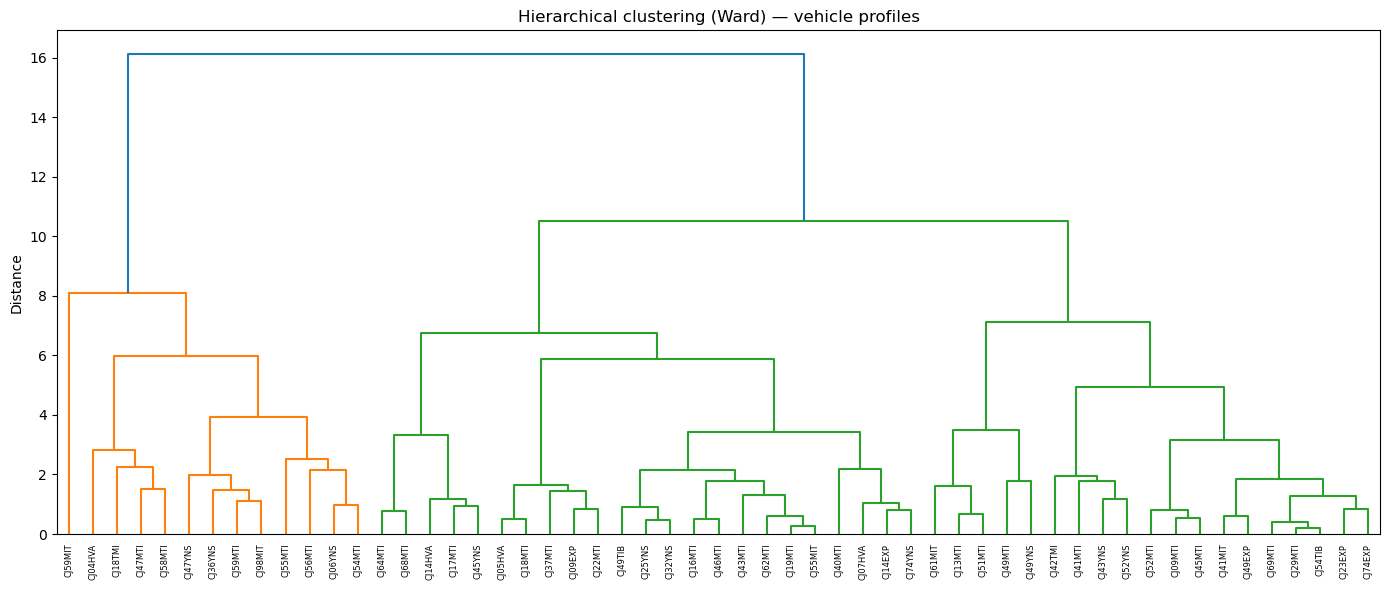

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, labels=vehicle_profiles["NumarInmatriculare"].tolist(), leaf_rotation=90)
plt.title("Hierarchical clustering (Ward) — vehicle profiles")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

c:\Users\Tudor\anaconda3\envs\ml-standard-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tudor\anaconda3\envs\ml-standard-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tudor\anaconda3\envs\ml-standard-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tudor\anaconda3\envs\ml-standard-env\Lib\site-packages\sklearn\c

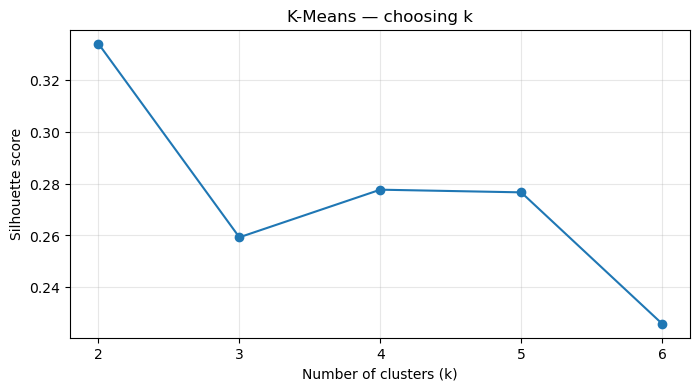

Best silhouette: k=2 (0.334)
Dendrogram suggests k=3 as a readable cut — used below.


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 7)
scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means — choosing k")
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_range)[scores.index(max(scores))]
print(f"Best silhouette: k={best_k} ({max(scores):.3f})")
print("Dendrogram suggests k=3 as a readable cut — used below.")

In [8]:
N_CLUSTERS = 3

vehicle_profiles["cluster_hier"] = fcluster(linked, N_CLUSTERS, criterion="maxclust") - 1
vehicle_profiles["cluster_kmeans"] = KMeans(
    n_clusters=N_CLUSTERS, random_state=42, n_init=10
).fit_predict(X_scaled)

vehicle_profiles[["NumarInmatriculare", "cluster_hier", "cluster_kmeans"]]

c:\Users\Tudor\anaconda3\envs\ml-standard-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,NumarInmatriculare,cluster_hier,cluster_kmeans
0,CJ04HVA,0,0
1,CJ05HVA,1,0
2,CJ06YNS,0,0
3,CJ07HVA,1,2
4,CJ09EXP,1,0
5,CJ09MTI,2,1
6,CJ13MTI,2,1
7,CJ14EXP,1,2
8,CJ14HVA,1,2
9,CJ16MTI,1,1


In [9]:
cluster_summary = (
    vehicle_profiles.groupby("cluster_kmeans")[FEATURES]
    .mean()
    .round(1)
)
cluster_sizes = vehicle_profiles["cluster_kmeans"].value_counts().sort_index()

print("Cluster sizes:", cluster_sizes.to_dict())
cluster_summary

Cluster sizes: {0: 17, 1: 25, 2: 13}


,n_refills,total_liters,total_spend,avg_fill,n_suppliers,loyalty_pct,premium_share
cluster_kmeans,,,,,,,
0,62.8,3850.6,25948.5,65.8,2.8,56.2,34.5
1,23.2,1068.4,7147.2,49.8,1.3,92.7,24.3
2,72.4,3106.8,21061.9,43.5,1.2,96.8,52.1


In [10]:
def label_cluster(row):
    if row["loyalty_pct"] >= 90 and row["premium_share"] >= 40:
        return "Premium loyal"
    if row["n_suppliers"] >= 2 and row["loyalty_pct"] < 80:
        return "Multi-brand active"
    return "Low-volume loyal"

cluster_summary["label"] = cluster_summary.apply(label_cluster, axis=1)
label_map = cluster_summary["label"].to_dict()

for cid, row in cluster_summary.iterrows():
    print(f"Cluster {cid} — {row['label']} (n={cluster_sizes[cid]}):")
    print(f"  refills={row.n_refills}, liters={row.total_liters}, loyalty={row.loyalty_pct}%, premium={row.premium_share}%")

vehicle_profiles["cluster_label"] = vehicle_profiles["cluster_kmeans"].map(label_map)

Cluster 0 — Multi-brand active (n=17):
  refills=62.8, liters=3850.6, loyalty=56.2%, premium=34.5%
Cluster 1 — Low-volume loyal (n=25):
  refills=23.2, liters=1068.4, loyalty=92.7%, premium=24.3%
Cluster 2 — Premium loyal (n=13):
  refills=72.4, liters=3106.8, loyalty=96.8%, premium=52.1%


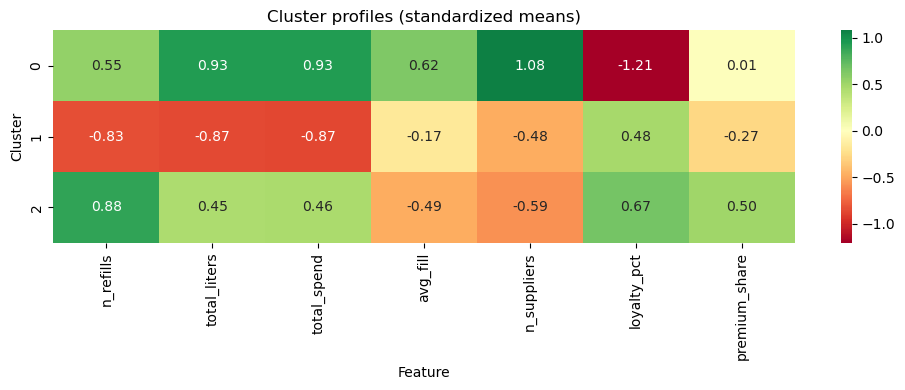

In [11]:
# heatmap of mean profile per cluster (z-scored for comparison)
profile_z = cluster_summary[FEATURES].copy()
for col in FEATURES:
    profile_z[col] = (profile_z[col] - vehicle_profiles[col].mean()) / vehicle_profiles[col].std()

plt.figure(figsize=(10, 4))
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Cluster profiles (standardized means)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

Raw variance per PC: [3.66382544 1.63058274]
Percentage of variance per PC: [0.51388721 0.22870511]


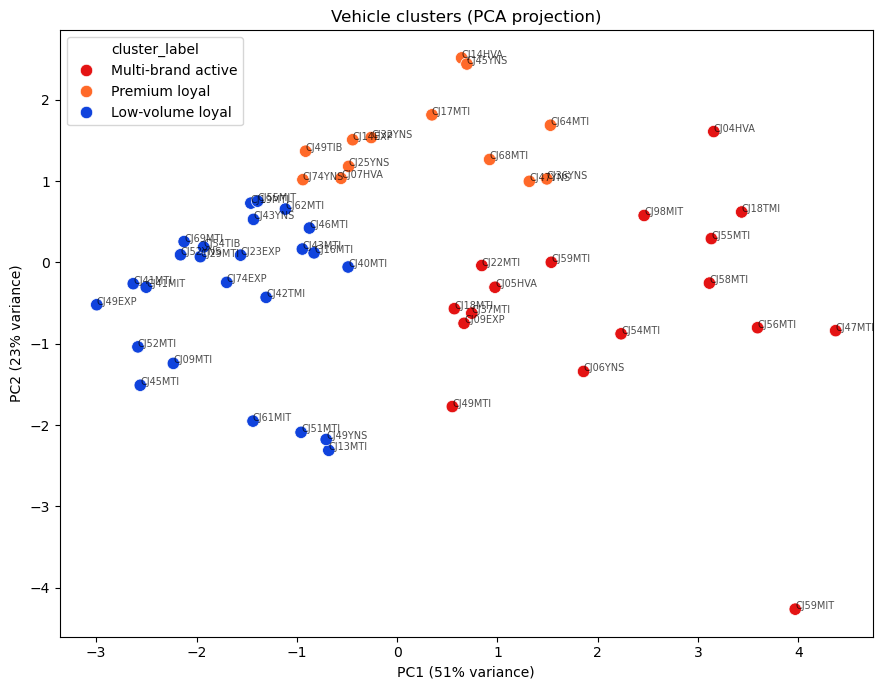

[3.66382544 1.63058274]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)


# 5. Get the percentage of variance (variance ratio)
print("Percentage of variance per PC:", pca.explained_variance_ratio_)


vehicle_profiles["pc1"] = coords[:, 0]
vehicle_profiles["pc2"] = coords[:, 1]

palette = {"Multi-brand active": "#E41313", "Low-volume loyal": "#1043DD", "Premium loyal": "#ff6929"}

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=vehicle_profiles,
    x="pc1",
    y="pc2",
    hue="cluster_label",
    palette=palette,
    s=80,
    edgecolor="white",
    linewidth=0.5,
)
for _, row in vehicle_profiles.iterrows():
    plt.annotate(row["NumarInmatriculare"], (row["pc1"], row["pc2"]), fontsize=7, alpha=0.7)

plt.title("Vehicle clusters (PCA projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
plt.tight_layout()
plt.show()
print(pca.explained_variance_)

In [13]:
agreement = (vehicle_profiles["cluster_hier"] == vehicle_profiles["cluster_kmeans"]).mean()
print(f"Hierarchical / K-Means agreement: {agreement:.0%} of vehicles")
print("Borderline vehicles may shift — K-Means labels used below (silhouette-validated).\n")

pd.crosstab(
    vehicle_profiles["cluster_hier"],
    vehicle_profiles["cluster_kmeans"],
    rownames=["Hierarchical"],
    colnames=["K-Means"],
)

Hierarchical / K-Means agreement: 33% of vehicles
Borderline vehicles may shift — K-Means labels used below (silhouette-validated).



K-Means,0,1,2
Hierarchical,,,
0,11,0,2
1,5,7,11
2,1,18,0


### Findings

Three vehicle groups emerge from consumption + supplier behavior:

- **Multi-brand active** — high activity, uses 2+ suppliers, loyalty below 80%
- **Low-volume loyal** — fewer refills, sticks to one supplier
- **Premium loyal** — heavy users, high loyalty, mostly premium diesel

The dendrogram and K-Means both suggest 3 groups; final labels come from **K-Means** (best silhouette at k=2, k=3 chosen for interpretability). Export `cluster_label` for ToscanaJ step 3.